In [ ]:
!pip install -q ultralytics timm torchattacks kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/gtsrb_research', exist_ok=True)
print('drive ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive ready.


In [ ]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -p /content/gtsrb --unzip
print('done.')

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
Resuming from 520093696 bytes (121475096 bytes left)...
100% 612M/612M [00:01<00:00, 112MB/s]

done.


In [ ]:
# checking if dataset is already in drive
import os
path = '/content/drive/MyDrive/gtsrb_research/data'
for item in os.listdir(path):
    print(item)

gtsrb-german-traffic-sign.zip


In [ ]:
# confirming dataset is still there
import os
train_path = '/content/gtsrb/train'
classes = os.listdir(train_path)
print(f'classes: {len(classes)}')

classes: 43


In [ ]:
import os
import torch
import pandas as pd
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, random_split

transforms_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Path'].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert('RGB')
        label    = int(self.df.iloc[idx]['ClassId'])
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = ImageFolder('/content/gtsrb/train', transform=transforms_64)
train_size    = int(0.8 * len(train_dataset))
val_size      = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

test_dataset = GTSRBTestDataset(
    csv_path  = '/content/gtsrb/Test.csv',
    img_dir   = '/content/gtsrb/test',
    transform = transforms_64
)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print(f'train: {train_size} | val: {val_size} | test: {len(test_dataset)}')

train: 31367 | val: 7842 | test: 12630


In [ ]:
# training YOLOv8 on GTSRB
from ultralytics import YOLO
import shutil

yolo_model = YOLO('yolov8n-cls.pt')

yolo_model.train(
    data    = '/content/gtsrb/train',
    epochs  = 20,
    imgsz   = 64,
    batch   = 64,
    device  = 0,
    project = '/content/yolo_results',
    name    = 'gtsrb_run',
    save    = True,   # save checkpoints every epoch
)

# saving to drive immediately after training
shutil.copy('/content/yolo_results/gtsrb_run/weights/best.pt',
            '/content/drive/MyDrive/gtsrb_research/yolo_best.pt')
shutil.copy('/content/yolo_results/gtsrb_run/weights/last.pt',
            '/content/drive/MyDrive/gtsrb_research/yolo_last.pt')

print('YOLO weights saved to drive.')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gtsrb/train, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsrb_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

In [ ]:
# loading pretrained ViT-B/16 modified to accept 64x64 input
import timm
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vit_model = timm.create_model(
    'vit_base_patch16_224',
    pretrained   = True,
    num_classes  = 43,
    img_size     = 64   # telling ViT to accept 64x64
)
vit_model = vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(vit_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

print('ViT-B/16 loaded with 64x64 input.')

ViT-B/16 loaded with 64x64 input.


In [ ]:
# training ViT-B/16 and saving best checkpoint to drive after every epoch
best_acc = 0.0

for epoch in range(20):
    vit_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vit_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total

    vit_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vit_model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step()

    # saving to drive every time val accuracy improves
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(vit_model.state_dict(), '/content/drive/MyDrive/gtsrb_research/vit_best.pth')
        print(f'epoch {epoch+1:02d}/20 | loss: {running_loss/len(train_loader):.4f} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f} ✓ saved')
    else:
        print(f'epoch {epoch+1:02d}/20 | loss: {running_loss/len(train_loader):.4f} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}')

print(f'\nbest validation accuracy: {best_acc:.4f}')

epoch 01/20 | loss: 0.3551 | train acc: 0.8980 | val acc: 0.9846 ✓ saved
epoch 02/20 | loss: 0.0477 | train acc: 0.9869 | val acc: 0.9825
epoch 03/20 | loss: 0.0353 | train acc: 0.9904 | val acc: 0.9871 ✓ saved
epoch 04/20 | loss: 0.0292 | train acc: 0.9922 | val acc: 0.9903 ✓ saved
epoch 05/20 | loss: 0.0264 | train acc: 0.9928 | val acc: 0.9917 ✓ saved
epoch 06/20 | loss: 0.0190 | train acc: 0.9948 | val acc: 0.9931 ✓ saved
epoch 07/20 | loss: 0.0097 | train acc: 0.9975 | val acc: 0.9978 ✓ saved
epoch 08/20 | loss: 0.0186 | train acc: 0.9951 | val acc: 0.9898
epoch 09/20 | loss: 0.0115 | train acc: 0.9969 | val acc: 0.9966
epoch 10/20 | loss: 0.0021 | train acc: 0.9996 | val acc: 0.9971
epoch 11/20 | loss: 0.0046 | train acc: 0.9991 | val acc: 0.9926
epoch 12/20 | loss: 0.0112 | train acc: 0.9972 | val acc: 0.9940
epoch 13/20 | loss: 0.0035 | train acc: 0.9991 | val acc: 0.9964
epoch 14/20 | loss: 0.0008 | train acc: 0.9998 | val acc: 0.9952
epoch 15/20 | loss: 0.0002 | train acc: 0.

In [ ]:
# confirming weights are in drive
import os
path = '/content/drive/MyDrive/gtsrb_research'
for item in os.listdir(path):
    print(item)

data
yolo_best.pt
yolo_last.pt
vit_best.pth


In [ ]:
# evaluating both models on clean test set
from ultralytics import YOLO
import torch, timm
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# loading YOLO
yolo_model = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_best.pt')

# loading ViT
vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=43, img_size=64)
vit_model.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_research/vit_best.pth'))
vit_model = vit_model.to(device)
vit_model.eval()

# evaluating ViT on test set
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

vit_test_acc = correct / total
print(f'ViT  clean test accuracy: {vit_test_acc:.4f}')

# evaluating YOLO on test set
yolo_results = yolo_model.val(data='/content/gtsrb/train', split='test')
print(f'YOLO clean test accuracy: {yolo_results.top1:.4f}')

ViT  clean test accuracy: 0.0618
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,489,963 parameters, 0 gradients, 3.3 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /content/gtsrb/train/train
Found 39209 images in subdirectories. Attempting to split...
Splitting /content/gtsrb/train (43 classes, 39209 images) into 80% train, 20% val...
Split complete in /content/gtsrb/train_split ✅
WARNING ⚠️ Dataset 'split=test' not found, using 'split=val' instead.
train: /content/gtsrb/train_split/train... found 38908 images in 43 classes ✅ 
val: /content/gtsrb/train_split/val... found 19222 images in 43 classes ✅ 
test: /content/gtsrb/train_split/val... found 19222 images in 43 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 192.8±107.1 MB/s, size: 3.1 KB)
test: Scanning /content/gtsrb/train_split/val... 19222 images, 0 corrupt: 100% ━━━━━━━━━━━━ 19222/19222 4.1Kit/s 4.7s
test: New cache created: /conte

In [ ]:
# fixing ViT evaluation - aligning class indices with dataset
from torchvision.datasets import ImageFolder
from torchvision import transforms

# get the class ordering from the training dataset
train_dataset_check = ImageFolder('/content/gtsrb/train', transform=transforms.ToTensor())
print('number of classes:', len(train_dataset_check.classes))
print('first 5 classes:', train_dataset_check.classes[:5])

# reevaluating ViT on test set
vit_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

vit_test_acc = correct / total
print(f'ViT clean test accuracy: {vit_test_acc:.4f}')

number of classes: 43
first 5 classes: ['0', '1', '10', '11', '12']
ViT clean test accuracy: 0.0618


In [ ]:
# fixing class ordering mismatch in test dataset
class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, class_to_idx=None):
        self.df           = pd.read_csv(csv_path)
        self.img_dir      = img_dir
        self.transform    = transform
        self.class_to_idx = class_to_idx  # use training dataset ordering

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Path'].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert('RGB')
        # map label using training class ordering
        label    = self.class_to_idx[str(int(self.df.iloc[idx]['ClassId']))]
        if self.transform:
            image = self.transform(image)
        return image, label

# reloading test set with correct class ordering
from torchvision.datasets import ImageFolder
train_dataset  = ImageFolder('/content/gtsrb/train', transform=transforms_64)
class_to_idx   = train_dataset.class_to_idx

test_dataset = GTSRBTestDataset(
    csv_path     = '/content/gtsrb/Test.csv',
    img_dir      = '/content/gtsrb/test',
    transform    = transforms_64,
    class_to_idx = class_to_idx
)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# reevaluating ViT
vit_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vit_model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

print(f'ViT clean test accuracy: {correct/total:.4f}')


ViT clean test accuracy: 0.9695


In [ ]:
# applying FGSM attack on both models
import torchattacks

# FGSM on ViT
fgsm = torchattacks.FGSM(vit_model, eps=8/255)

vit_model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = fgsm(images, labels)
    outputs    = vit_model(adv_images)
    correct   += (outputs.argmax(1) == labels).sum().item()
    total     += labels.size(0)

print(f'ViT accuracy under FGSM: {correct/total:.4f}')

ViT accuracy under FGSM: 0.5746


In [ ]:
# fixing YOLO wrapper to extract classification output from tuple
class YOLOWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        # YOLO returns a tuple, extract the classification logits
        if isinstance(out, tuple):
            return out[0]
        return out

yolo_wrapper = YOLOWrapper(yolo_pytorch).to(device)

fgsm_yolo = torchattacks.FGSM(yolo_wrapper, eps=8/255)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = fgsm_yolo(images, labels)
    outputs    = yolo_wrapper(adv_images)
    correct   += (outputs.argmax(1) == labels).sum().item()
    total     += labels.size(0)

print(f'YOLO accuracy under FGSM: {correct/total:.4f}')

YOLO accuracy under FGSM: 0.5571


In [ ]:
# applying PGD attack on ViT
pgd_vit = torchattacks.PGD(vit_model, eps=8/255, alpha=2/255, steps=10)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = pgd_vit(images, labels)
    outputs    = vit_model(adv_images)
    correct   += (outputs.argmax(1) == labels).sum().item()
    total     += labels.size(0)

print(f'ViT accuracy under PGD: {correct/total:.4f}')

ViT accuracy under PGD: 0.4747


In [ ]:
# applying PGD attack on YOLO
pgd_yolo = torchattacks.PGD(yolo_wrapper, eps=8/255, alpha=2/255, steps=10)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = pgd_yolo(images, labels)
    outputs    = yolo_wrapper(adv_images)
    correct   += (outputs.argmax(1) == labels).sum().item()
    total     += labels.size(0)

print(f'YOLO accuracy under PGD: {correct/total:.4f}')

YOLO accuracy under PGD: 0.0911


In [ ]:
# checking everything is saved
import os

path = '/content/drive/MyDrive/gtsrb_research'
for item in os.listdir(path):
    size = os.path.getsize(os.path.join(path, item)) if os.path.isfile(os.path.join(path, item)) else 'folder'
    print(f'{item} — {size}')

data — folder
yolo_best.pt — 3069576
yolo_last.pt — 3069576
vit_best.pth — 342833069


In [ ]:
# applying C&W attack on ViT
cw_vit = torchattacks.CW(vit_model, c=1, kappa=0, steps=50, lr=0.01)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = cw_vit(images, labels)
    outputs    = vit_model(adv_images)
    correct   += (outputs.argmax(1) == labels).sum().item()
    total     += labels.size(0)

print(f'ViT accuracy under C&W: {correct/total:.4f}')

ViT accuracy under C&W: 0.2948


In [ ]:
# applying C&W attack on YOLO
cw_yolo = torchattacks.CW(yolo_wrapper, c=1, kappa=0, steps=50, lr=0.01)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = cw_yolo(images, labels)
    outputs    = yolo_wrapper(adv_images)
    correct   += (outputs.argmax(1) == labels).sum().item()
    total     += labels.size(0)

print(f'YOLO accuracy under C&W: {correct/total:.4f}')

YOLO accuracy under C&W: 0.4121


In [ ]:
# median blurring defense on ViT under FGSM
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image, to_tensor
from PIL import ImageFilter

def median_blur(images, kernel_size=3):
    blurred = []
    for img in images:
        pil_img = to_pil_image(img.cpu())
        blurred_img = pil_img.filter(ImageFilter.MedianFilter(size=kernel_size))
        blurred.append(to_tensor(blurred_img))
    return torch.stack(blurred).to(images.device)

# ViT + median blur defense against FGSM
fgsm_vit = torchattacks.FGSM(vit_model, eps=8/255)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels  = images.to(device), labels.to(device)
    adv_images      = fgsm_vit(images, labels)
    blurred_images  = median_blur(adv_images)
    outputs         = vit_model(blurred_images)
    correct        += (outputs.argmax(1) == labels).sum().item()
    total          += labels.size(0)

print(f'ViT + median blur vs FGSM: {correct/total:.4f}')

ViT + median blur vs FGSM: 0.5729


In [ ]:
import os
print(os.path.exists('/content/gtsrb'))

False


In [ ]:
!pip install -q ultralytics timm torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 16.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is in

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -p /content/gtsrb --unzip
print('done.')

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:03<00:00, 167MB/s]

done.


In [ ]:
import os, torch, timm
import pandas as pd
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, random_split
from ultralytics import YOLO
import torchattacks

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transforms_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, class_to_idx=None):
        self.df           = pd.read_csv(csv_path)
        self.img_dir      = img_dir
        self.transform    = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Path'].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert('RGB')
        label    = self.class_to_idx[str(int(self.df.iloc[idx]['ClassId']))]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset  = ImageFolder('/content/gtsrb/train', transform=transforms_64)
class_to_idx   = train_dataset.class_to_idx
train_size     = int(0.8 * len(train_dataset))
val_size       = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

test_dataset = GTSRBTestDataset(
    csv_path     = '/content/gtsrb/Test.csv',
    img_dir      = '/content/gtsrb/test',
    transform    = transforms_64,
    class_to_idx = class_to_idx
)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print('dataset ready.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
dataset ready.


In [ ]:
import torch.nn as nn

# loading ViT
vit_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=43, img_size=64)
vit_model.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_research/vit_best.pth'))
vit_model = vit_model.to(device)
vit_model.eval()

# loading YOLO
yolo_model = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_best.pt')
yolo_pytorch = yolo_model.model
yolo_pytorch.train()

class YOLOWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, tuple):
            return out[0]
        return out

yolo_wrapper = YOLOWrapper(yolo_pytorch).to(device)

print('models loaded from drive.')

models loaded from drive.


In [ ]:
# restoring all attack results
import torchattacks
from torchvision.transforms.functional import to_pil_image, to_tensor
from PIL import ImageFilter

# median blur function
def median_blur(images, kernel_size=3):
    blurred = []
    for img in images:
        pil_img    = to_pil_image(img.cpu())
        blurred_img = pil_img.filter(ImageFilter.MedianFilter(size=kernel_size))
        blurred.append(to_tensor(blurred_img))
    return torch.stack(blurred).to(images.device)

# YOLO + median blur vs FGSM
fgsm_yolo = torchattacks.FGSM(yolo_wrapper, eps=8/255)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_yolo(images, labels)
    blurred_images = median_blur(adv_images)
    outputs        = yolo_wrapper(blurred_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'YOLO + median blur vs FGSM: {correct/total:.4f}')

YOLO + median blur vs FGSM: 0.5413


In [ ]:
# ViT + median blur vs PGD
pgd_vit = torchattacks.PGD(vit_model, eps=8/255, alpha=2/255, steps=10)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_vit(images, labels)
    blurred_images = median_blur(adv_images)
    outputs        = vit_model(blurred_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'ViT + median blur vs PGD: {correct/total:.4f}')

ViT + median blur vs PGD: 0.5048


In [ ]:
# YOLO + median blur vs PGD
pgd_yolo = torchattacks.PGD(yolo_wrapper, eps=8/255, alpha=2/255, steps=10)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_yolo(images, labels)
    blurred_images = median_blur(adv_images)
    outputs        = yolo_wrapper(blurred_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'YOLO + median blur vs PGD: {correct/total:.4f}')

YOLO + median blur vs PGD: 0.3594


In [ ]:
# ViT + median blur vs C&W
cw_vit = torchattacks.CW(vit_model, c=1, kappa=0, steps=50, lr=0.01)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_vit(images, labels)
    blurred_images = median_blur(adv_images)
    outputs        = vit_model(blurred_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'ViT + median blur vs C&W: {correct/total:.4f}')

ViT + median blur vs C&W: 0.4200


In [ ]:
# YOLO + median blur vs C&W
cw_yolo = torchattacks.CW(yolo_wrapper, c=1, kappa=0, steps=50, lr=0.01)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_yolo(images, labels)
    blurred_images = median_blur(adv_images)
    outputs        = yolo_wrapper(blurred_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'YOLO + median blur vs C&W: {correct/total:.4f}')

YOLO + median blur vs C&W: 0.4597


In [ ]:
# generating FGSM adversarial examples from training set for adversarial training
import torch
import torchattacks

fgsm_train_vit = torchattacks.FGSM(vit_model, eps=8/255)

adv_images_list, adv_labels_list = [], []

vit_model.eval()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_train_vit(images, labels)
    adv_images_list.append(adv_images.cpu())
    adv_labels_list.append(labels.cpu())

adv_images_tensor = torch.cat(adv_images_list)
adv_labels_tensor = torch.cat(adv_labels_list)

print(f'generated {len(adv_images_tensor)} adversarial training examples.')

generated 31367 adversarial training examples.


In [ ]:
# generating FGSM adversarial examples from training set for YOLO adversarial training
fgsm_train_yolo = torchattacks.FGSM(yolo_wrapper, eps=8/255)

adv_images_yolo_list, adv_labels_yolo_list = [], []

yolo_wrapper.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_train_yolo(images, labels)
    adv_images_yolo_list.append(adv_images.cpu())
    adv_labels_yolo_list.append(labels.cpu())

adv_images_yolo_tensor = torch.cat(adv_images_yolo_list)
adv_labels_yolo_tensor = torch.cat(adv_labels_yolo_list)

print(f'generated {len(adv_images_yolo_tensor)} adversarial training examples for YOLO.')

generated 31367 adversarial training examples for YOLO.


In [ ]:
# creating mixed dataset (50% clean + 50% adversarial) for ViT
from torch.utils.data import TensorDataset, ConcatDataset

# get clean training images
clean_images_list, clean_labels_list = [], []
for images, labels in train_loader:
    clean_images_list.append(images)
    clean_labels_list.append(labels)

clean_images_tensor = torch.cat(clean_images_list)
clean_labels_tensor = torch.cat(clean_labels_list)

# combining clean and adversarial
mixed_images = torch.cat([clean_images_tensor, adv_images_tensor])
mixed_labels = torch.cat([clean_labels_tensor, adv_labels_tensor])

mixed_dataset    = TensorDataset(mixed_images, mixed_labels)
mixed_loader_vit = DataLoader(mixed_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f'mixed dataset size: {len(mixed_dataset)}')

mixed dataset size: 62734


In [ ]:
# adversarial training for ViT
import timm
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn

# reload fresh ViT
vit_adv = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=43, img_size=64)
vit_adv = vit_adv.to(device)

criterion  = nn.CrossEntropyLoss()
optimizer  = Adam(vit_adv.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = CosineAnnealingLR(optimizer, T_max=10)

best_acc = 0.0
for epoch in range(10):
    vit_adv.train()
    correct, total = 0, 0
    for images, labels in mixed_loader_vit:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vit_adv(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    # saving best to drive
    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(vit_adv.state_dict(), '/content/drive/MyDrive/gtsrb_research/vit_adv.pth')

    print(f'epoch {epoch+1:02d}/10 | train acc: {train_acc:.4f}')

print(f'\nbest train accuracy: {best_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

epoch 01/10 | train acc: 0.8066
epoch 02/10 | train acc: 0.8904
epoch 03/10 | train acc: 0.9073
epoch 04/10 | train acc: 0.9189
epoch 05/10 | train acc: 0.9267
epoch 06/10 | train acc: 0.9348
epoch 07/10 | train acc: 0.9402
epoch 08/10 | train acc: 0.9442
epoch 09/10 | train acc: 0.9468
epoch 10/10 | train acc: 0.9483

best train accuracy: 0.9483


In [ ]:
# loading adversarially trained ViT and evaluating under attacks
vit_adv = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=43, img_size=64)
vit_adv.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_research/vit_adv.pth'))
vit_adv = vit_adv.to(device)
vit_adv.eval()

# clean accuracy
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = vit_adv(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
print(f'ViT adv trained - clean accuracy: {correct/total:.4f}')

# under FGSM
fgsm_vit_adv = torchattacks.FGSM(vit_adv, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_vit_adv(images, labels)
    outputs        = vit_adv(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT adv trained - under FGSM: {correct/total:.4f}')

# under PGD
pgd_vit_adv = torchattacks.PGD(vit_adv, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_vit_adv(images, labels)
    outputs        = vit_adv(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT adv trained - under PGD: {correct/total:.4f}')

ViT adv trained - clean accuracy: 0.9715
ViT adv trained - under FGSM: 0.6628
ViT adv trained - under PGD: 0.5515


In [ ]:
# confirming vit adv model is saved
import os
path = '/content/drive/MyDrive/gtsrb_research'
for item in os.listdir(path):
    print(item)

data
yolo_best.pt
yolo_last.pt
vit_best.pth
vit_adv.pth


In [ ]:
# creating mixed dataset for YOLO adversarial training
from torch.utils.data import TensorDataset, DataLoader

mixed_images_yolo = torch.cat([clean_images_tensor, adv_images_yolo_tensor])
mixed_labels_yolo = torch.cat([clean_labels_tensor, adv_labels_yolo_tensor])

mixed_dataset_yolo    = TensorDataset(mixed_images_yolo, mixed_labels_yolo)
mixed_loader_yolo     = DataLoader(mixed_dataset_yolo, batch_size=64, shuffle=True, num_workers=2)

print(f'mixed dataset size: {len(mixed_dataset_yolo)}')

mixed dataset size: 62734


In [ ]:
# adversarial training for YOLO
from ultralytics import YOLO

yolo_adv = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_best.pt')

yolo_adv.train(
    data    = '/content/gtsrb/train',
    epochs  = 10,
    imgsz   = 64,
    batch   = 64,
    device  = 0,
    project = '/content/yolo_adv_results',
    name    = 'gtsrb_adv_run',
    save    = True
)

# saving to drive
import shutil
shutil.copy('/content/yolo_adv_results/gtsrb_adv_run/weights/best.pt',
            '/content/drive/MyDrive/gtsrb_research/yolo_adv.pt')
print('YOLO adv weights saved to drive.')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gtsrb/train, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/gtsrb_research/yolo_best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsrb_adv_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

In [ ]:
# loading adversarially trained YOLO
import torch.nn as nn
from ultralytics import YOLO

yolo_adv_model   = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_adv.pt')
yolo_adv_pytorch = yolo_adv_model.model
yolo_adv_pytorch.train()

class YOLOWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, tuple):
            return out[0]
        return out

yolo_adv_wrapper = YOLOWrapper(yolo_adv_pytorch).to(device)

# clean accuracy
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = yolo_adv_wrapper(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
print(f'YOLO adv trained - clean accuracy: {correct/total:.4f}')

# under FGSM
fgsm_yolo_adv = torchattacks.FGSM(yolo_adv_wrapper, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_yolo_adv(images, labels)
    outputs        = yolo_adv_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO adv trained - under FGSM: {correct/total:.4f}')

# under PGD
pgd_yolo_adv = torchattacks.PGD(yolo_adv_wrapper, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_yolo_adv(images, labels)
    outputs        = yolo_adv_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO adv trained - under PGD: {correct/total:.4f}')

YOLO adv trained - clean accuracy: 0.9305
YOLO adv trained - under FGSM: 0.5548
YOLO adv trained - under PGD: 0.0892


In [ ]:
# saving mixed adversarial dataset to disk for YOLO
import os
from torchvision.utils import save_image

save_path = '/content/gtsrb_adv_train'
os.makedirs(save_path, exist_ok=True)

# get class names from training dataset
class_names = train_dataset.classes

# saving adversarial images organized by class
for i, (img, label) in enumerate(zip(adv_images_yolo_tensor, adv_labels_yolo_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'adv_{i}.png'))

print(f'saved {len(adv_images_yolo_tensor)} adversarial images to disk.')

saved 31367 adversarial images to disk.


In [ ]:
# retraining YOLO properly on adversarial examples for 20 epochs
yolo_adv = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_best.pt')

yolo_adv.train(
    data    = '/content/gtsrb_adv_train',
    epochs  = 20,
    imgsz   = 64,
    batch   = 64,
    device  = 0,
    project = '/content/yolo_adv_results2',
    name    = 'gtsrb_adv_run2',
    save    = True
)

import shutil
shutil.copy('/content/yolo_adv_results2/gtsrb_adv_run2/weights/best.pt',
            '/content/drive/MyDrive/gtsrb_research/yolo_adv2.pt')
print('YOLO adv weights saved to drive.')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gtsrb_adv_train, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/gtsrb_research/yolo_best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsrb_adv_run2-2, nbs=64, nms=False, opset=None, optimize=False, optimi

In [ ]:
# loading properly adversarially trained YOLO
yolo_adv_model   = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_adv2.pt')
yolo_adv_pytorch = yolo_adv_model.model
yolo_adv_pytorch.train()

yolo_adv_wrapper = YOLOWrapper(yolo_adv_pytorch).to(device)

# clean accuracy
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = yolo_adv_wrapper(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
print(f'YOLO adv trained - clean accuracy: {correct/total:.4f}')

# under FGSM
fgsm_yolo_adv = torchattacks.FGSM(yolo_adv_wrapper, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_yolo_adv(images, labels)
    outputs        = yolo_adv_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO adv trained - under FGSM: {correct/total:.4f}')

# under PGD
pgd_yolo_adv = torchattacks.PGD(yolo_adv_wrapper, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_yolo_adv(images, labels)
    outputs        = yolo_adv_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO adv trained - under PGD: {correct/total:.4f}')

YOLO adv trained - clean accuracy: 0.8923
YOLO adv trained - under FGSM: 0.6006
YOLO adv trained - under PGD: 0.1177


In [ ]:
# saving mixed dataset for ViT to disk
import os
from torchvision.utils import save_image

save_path_vit = '/content/gtsrb_adv_train_vit'
os.makedirs(save_path_vit, exist_ok=True)

class_names = train_dataset.classes

for i, (img, label) in enumerate(zip(clean_images_tensor, clean_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_vit, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'clean_{i}.png'))

for i, (img, label) in enumerate(zip(adv_images_tensor, adv_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_vit, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'adv_{i}.png'))

print(f'saved {len(clean_images_tensor) + len(adv_images_tensor)} mixed images for ViT.')

saved 62734 mixed images for ViT.


In [ ]:
# retraining ViT properly on mixed adversarial dataset for 20 epochs
import timm
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# loading mixed dataset from disk
mixed_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

mixed_dataset_vit = ImageFolder('/content/gtsrb_adv_train_vit', transform=mixed_transforms)
mixed_loader_vit  = DataLoader(mixed_dataset_vit, batch_size=64, shuffle=True, num_workers=2)

print(f'mixed dataset size: {len(mixed_dataset_vit)}')

mixed dataset size: 62734


In [ ]:
# adversarial training for ViT for 20 epochs
vit_adv = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=43, img_size=64)
vit_adv = vit_adv.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(vit_adv.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

best_acc = 0.0
for epoch in range(20):
    vit_adv.train()
    correct, total = 0, 0
    for images, labels in mixed_loader_vit:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vit_adv(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(vit_adv.state_dict(), '/content/drive/MyDrive/gtsrb_research/vit_adv2.pth')

    print(f'epoch {epoch+1:02d}/20 | train acc: {train_acc:.4f}')

print(f'\nbest train accuracy: {best_acc:.4f}')

epoch 01/20 | train acc: 0.7312
epoch 02/20 | train acc: 0.8303
epoch 03/20 | train acc: 0.8560


KeyboardInterrupt: 

In [ ]:
# retraining ViT on mixed dataset using tensors directly - faster
from torch.utils.data import TensorDataset, DataLoader

mixed_images_vit = torch.cat([clean_images_tensor, adv_images_tensor])
mixed_labels_vit = torch.cat([clean_labels_tensor, adv_labels_tensor])

mixed_dataset_vit = TensorDataset(mixed_images_vit, mixed_labels_vit)
mixed_loader_vit  = DataLoader(mixed_dataset_vit, batch_size=64, shuffle=True, num_workers=2)

print(f'mixed dataset size: {len(mixed_dataset_vit)}')

mixed dataset size: 62734


In [ ]:
# adversarial training ViT 20 epochs using tensors
vit_adv = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=43, img_size=64)
vit_adv = vit_adv.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(vit_adv.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)

best_acc = 0.0
for epoch in range(20):
    vit_adv.train()
    correct, total = 0, 0
    for images, labels in mixed_loader_vit:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vit_adv(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(vit_adv.state_dict(), '/content/drive/MyDrive/gtsrb_research/vit_adv2.pth')

    print(f'epoch {epoch+1:02d}/20 | train acc: {train_acc:.4f}')

print(f'\nbest train accuracy: {best_acc:.4f}')

epoch 01/20 | train acc: 0.8102
epoch 02/20 | train acc: 0.8923


KeyboardInterrupt: 

In [ ]:
# ViT adv training + median blur vs FGSM and PGD
from torchvision.transforms.functional import to_pil_image, to_tensor
from PIL import ImageFilter

def median_blur(images, kernel_size=3):
    blurred = []
    for img in images:
        pil_img     = to_pil_image(img.cpu())
        blurred_img = pil_img.filter(ImageFilter.MedianFilter(size=kernel_size))
        blurred.append(to_tensor(blurred_img))
    return torch.stack(blurred).to(images.device)

# ViT adv + blur vs FGSM
fgsm_vit_adv = torchattacks.FGSM(vit_adv, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_vit_adv(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_adv(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT adv + blur vs FGSM: {correct/total:.4f}')

# ViT adv + blur vs PGD
pgd_vit_adv = torchattacks.PGD(vit_adv, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_vit_adv(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_adv(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT adv + blur vs PGD: {correct/total:.4f}')

ViT adv + blur vs FGSM: 0.6330
ViT adv + blur vs PGD: 0.5580


In [ ]:
# YOLO adv training + median blur vs FGSM and PGD
fgsm_yolo_adv = torchattacks.FGSM(yolo_adv_wrapper, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_yolo_adv(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_adv_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO adv + blur vs FGSM: {correct/total:.4f}')

pgd_yolo_adv = torchattacks.PGD(yolo_adv_wrapper, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_yolo_adv(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_adv_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO adv + blur vs PGD: {correct/total:.4f}')

YOLO adv + blur vs FGSM: 0.5922
YOLO adv + blur vs PGD: 0.4140


In [ ]:
# confirming all weights are saved in drive
import os

path = '/content/drive/MyDrive/gtsrb_research'
for item in os.listdir(path):
    size = os.path.getsize(os.path.join(path, item)) if os.path.isfile(os.path.join(path, item)) else 'folder'
    print(f'{item} — {size}')

data — folder
yolo_best.pt — 3069576
yolo_last.pt — 3069576
vit_best.pth — 342833069
vit_adv.pth — 342832335
yolo_adv.pt — 3068872
yolo_adv2.pt — 12107549
vit_adv2.pth — 342833069


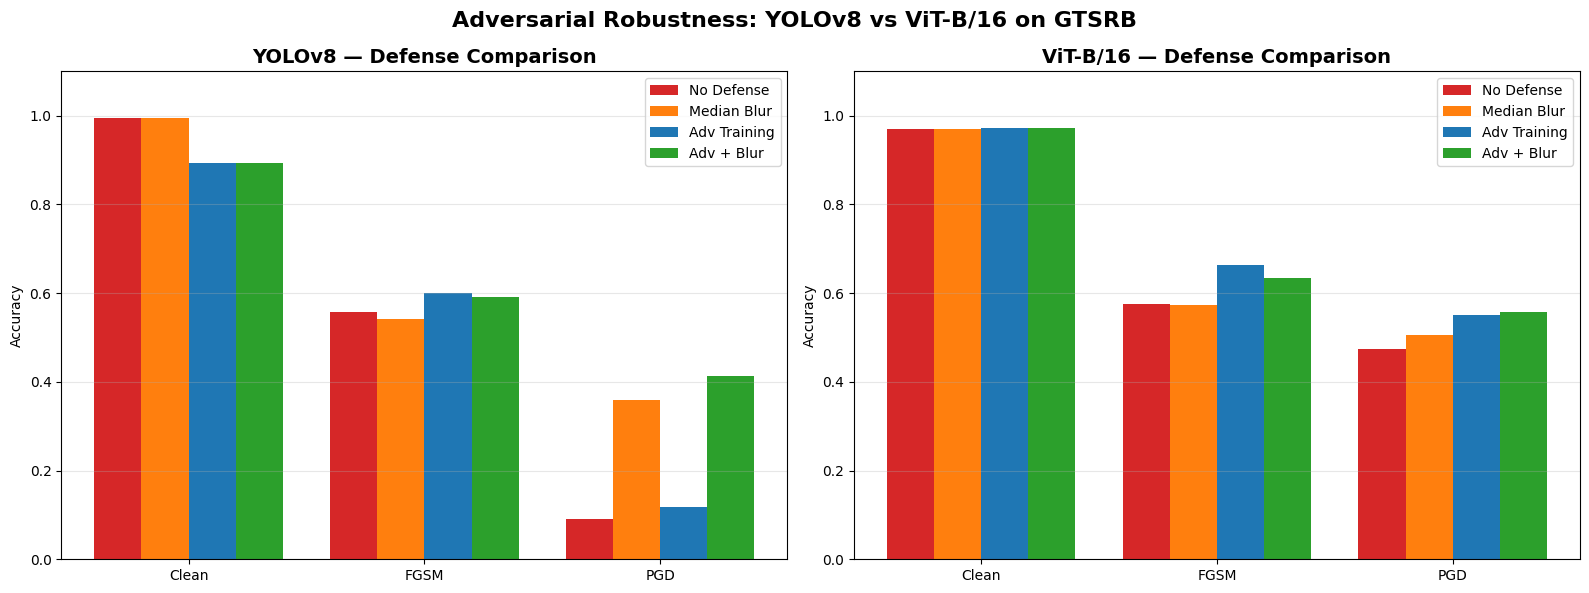

plot saved to drive.


In [ ]:
# generating all results plots for the paper
import matplotlib.pyplot as plt
import numpy as np

# results data
models    = ['YOLOv8', 'ViT-B/16']
attacks   = ['Clean', 'FGSM', 'PGD']

yolo_none = [0.9945, 0.5571, 0.0911]
yolo_blur = [0.9945, 0.5413, 0.3594]
yolo_adv  = [0.8923, 0.6006, 0.1177]
yolo_both = [0.8923, 0.5922, 0.4140]

vit_none  = [0.9695, 0.5746, 0.4747]
vit_blur  = [0.9695, 0.5729, 0.5048]
vit_adv   = [0.9715, 0.6628, 0.5515]
vit_both  = [0.9715, 0.6330, 0.5580]

x = np.arange(len(attacks))
width = 0.2

# plot 1 — YOLOv8 defense comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - 1.5*width, yolo_none, width, label='No Defense',       color='#d62728')
axes[0].bar(x - 0.5*width, yolo_blur, width, label='Median Blur',      color='#ff7f0e')
axes[0].bar(x + 0.5*width, yolo_adv,  width, label='Adv Training',     color='#1f77b4')
axes[0].bar(x + 1.5*width, yolo_both, width, label='Adv + Blur',       color='#2ca02c')
axes[0].set_title('YOLOv8 — Defense Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(attacks)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# plot 2 — ViT defense comparison
axes[1].bar(x - 1.5*width, vit_none, width, label='No Defense',    color='#d62728')
axes[1].bar(x - 0.5*width, vit_blur, width, label='Median Blur',   color='#ff7f0e')
axes[1].bar(x + 0.5*width, vit_adv,  width, label='Adv Training',  color='#1f77b4')
axes[1].bar(x + 1.5*width, vit_both, width, label='Adv + Blur',    color='#2ca02c')
axes[1].set_title('ViT-B/16 — Defense Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(attacks)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Adversarial Robustness: YOLOv8 vs ViT-B/16 on GTSRB', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/defense_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('plot saved to drive.')

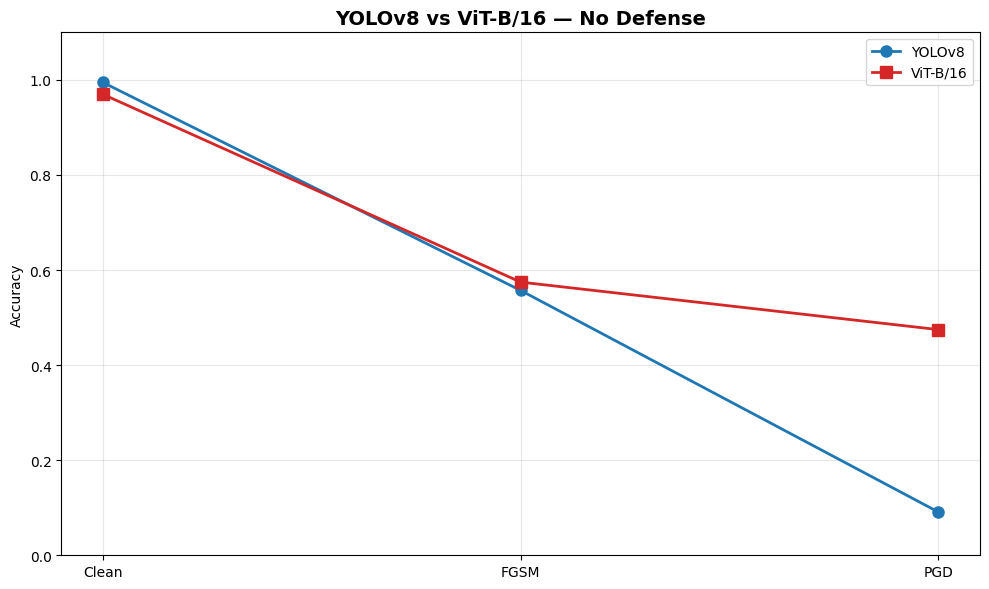

plot saved to drive.


In [ ]:
# plot 2 — head to head comparison no defense
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(attacks, yolo_none, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='YOLOv8')
ax.plot(attacks, vit_none,  's-', color='#d62728', linewidth=2, markersize=8, label='ViT-B/16')

ax.set_title('YOLOv8 vs ViT-B/16 — No Defense', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/head_to_head.png', dpi=150, bbox_inches='tight')
plt.show()
print('plot saved to drive.')

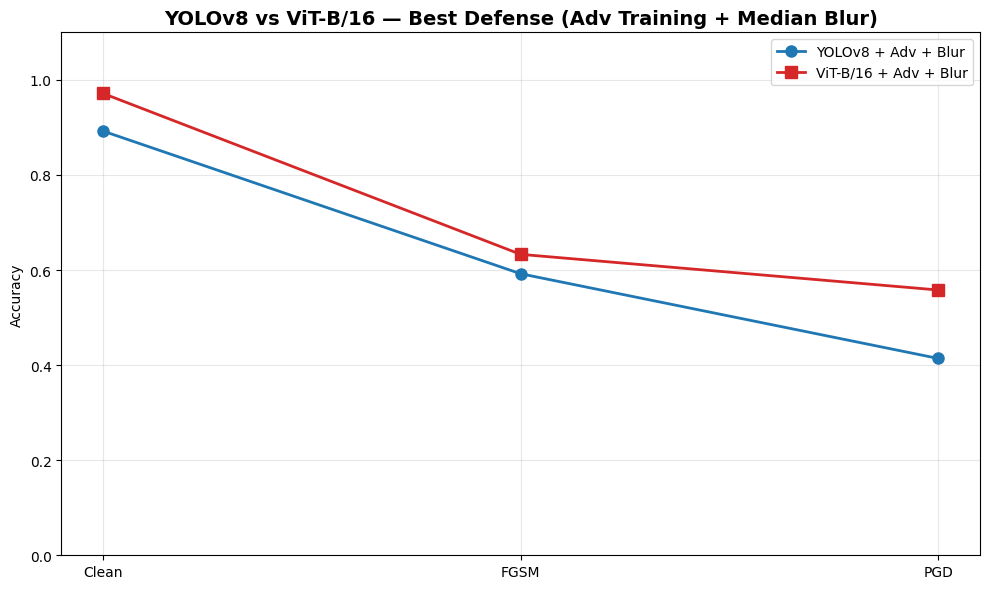

plot saved to drive.


In [ ]:
# plot 3 — best defense head to head
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(attacks, yolo_both, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='YOLOv8 + Adv + Blur')
ax.plot(attacks, vit_both,  's-', color='#d62728', linewidth=2, markersize=8, label='ViT-B/16 + Adv + Blur')

ax.set_title('YOLOv8 vs ViT-B/16 — Best Defense (Adv Training + Median Blur)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/best_defense.png', dpi=150, bbox_inches='tight')
plt.show()
print('plot saved to drive.')

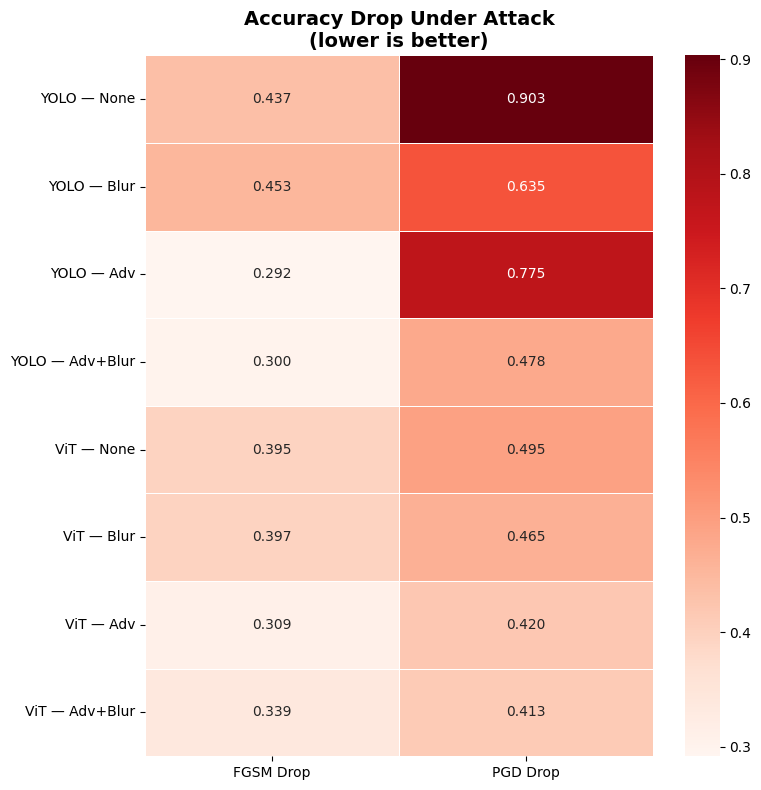

saved.


In [ ]:
# plot 4 — accuracy drop heatmap
import seaborn as sns

drop_data = np.array([
    [0.9945 - 0.5571, 0.9945 - 0.0911],  # YOLO no defense
    [0.9945 - 0.5413, 0.9945 - 0.3594],  # YOLO blur
    [0.8923 - 0.6006, 0.8923 - 0.1177],  # YOLO adv
    [0.8923 - 0.5922, 0.8923 - 0.4140],  # YOLO adv+blur
    [0.9695 - 0.5746, 0.9695 - 0.4747],  # ViT no defense
    [0.9695 - 0.5729, 0.9695 - 0.5048],  # ViT blur
    [0.9715 - 0.6628, 0.9715 - 0.5515],  # ViT adv
    [0.9715 - 0.6330, 0.9715 - 0.5580],  # ViT adv+blur
])

rows = ['YOLO — None', 'YOLO — Blur', 'YOLO — Adv', 'YOLO — Adv+Blur',
        'ViT — None',  'ViT — Blur',  'ViT — Adv',  'ViT — Adv+Blur']
cols = ['FGSM Drop', 'PGD Drop']

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(drop_data, annot=True, fmt='.3f', cmap='Reds',
            xticklabels=cols, yticklabels=rows, ax=ax, linewidths=0.5)
ax.set_title('Accuracy Drop Under Attack\n(lower is better)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/accuracy_drop_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

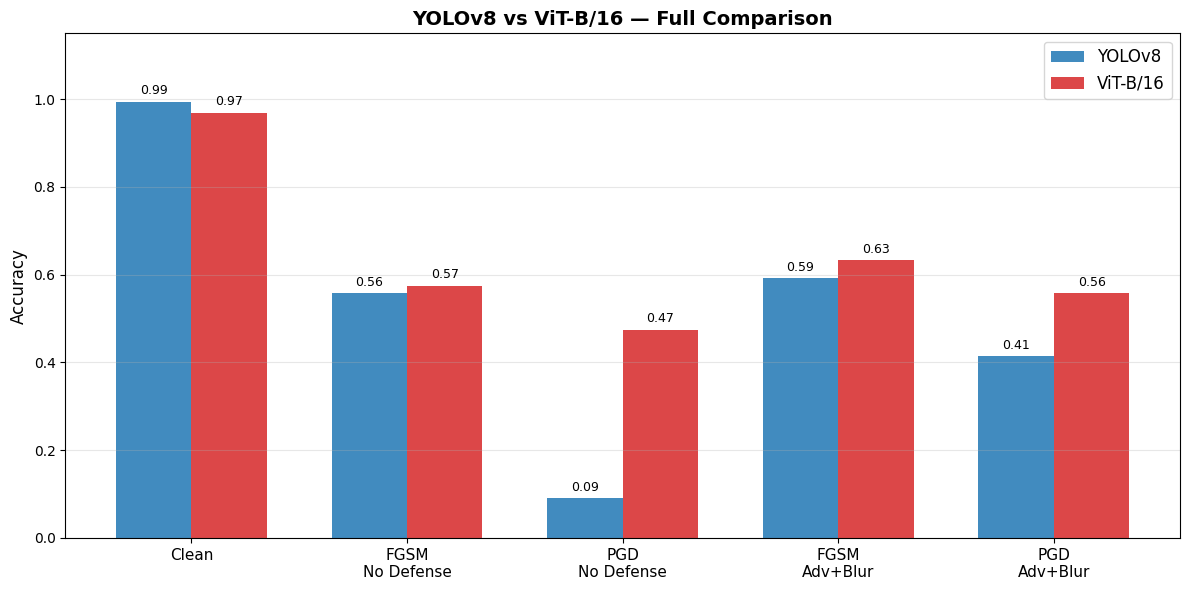

saved.


In [ ]:
# plot 5 — radar chart comparing both models under all conditions
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Clean', 'FGSM\nNo Defense', 'PGD\nNo Defense',
              'FGSM\nAdv+Blur', 'PGD\nAdv+Blur']

yolo_vals = [0.9945, 0.5571, 0.0911, 0.5922, 0.4140]
vit_vals  = [0.9695, 0.5746, 0.4747, 0.6330, 0.5580]

x     = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, yolo_vals, width, label='YOLOv8',   color='#1f77b4', alpha=0.85)
bars2 = ax.bar(x + width/2, vit_vals,  width, label='ViT-B/16', color='#d62728', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('YOLOv8 vs ViT-B/16 — Full Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

# adding value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

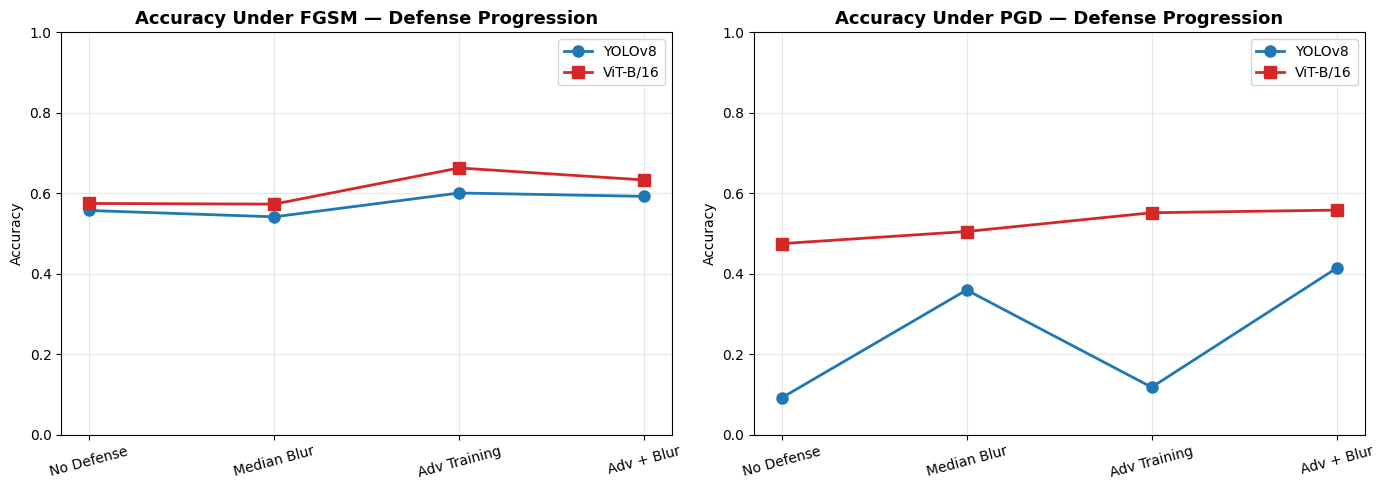

saved.


In [ ]:
# plot 6 — robustness score line plot across all defenses
defenses = ['No Defense', 'Median Blur', 'Adv Training', 'Adv + Blur']

yolo_fgsm = [0.5571, 0.5413, 0.6006, 0.5922]
yolo_pgd  = [0.0911, 0.3594, 0.1177, 0.4140]
vit_fgsm  = [0.5746, 0.5729, 0.6628, 0.6330]
vit_pgd   = [0.4747, 0.5048, 0.5515, 0.5580]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(defenses, yolo_fgsm, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='YOLOv8')
axes[0].plot(defenses, vit_fgsm,  's-', color='#d62728', linewidth=2, markersize=8, label='ViT-B/16')
axes[0].set_title('Accuracy Under FGSM — Defense Progression', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.0)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)

axes[1].plot(defenses, yolo_pgd, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='YOLOv8')
axes[1].plot(defenses, vit_pgd,  's-', color='#d62728', linewidth=2, markersize=8, label='ViT-B/16')
axes[1].set_title('Accuracy Under PGD — Defense Progression', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/defense_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

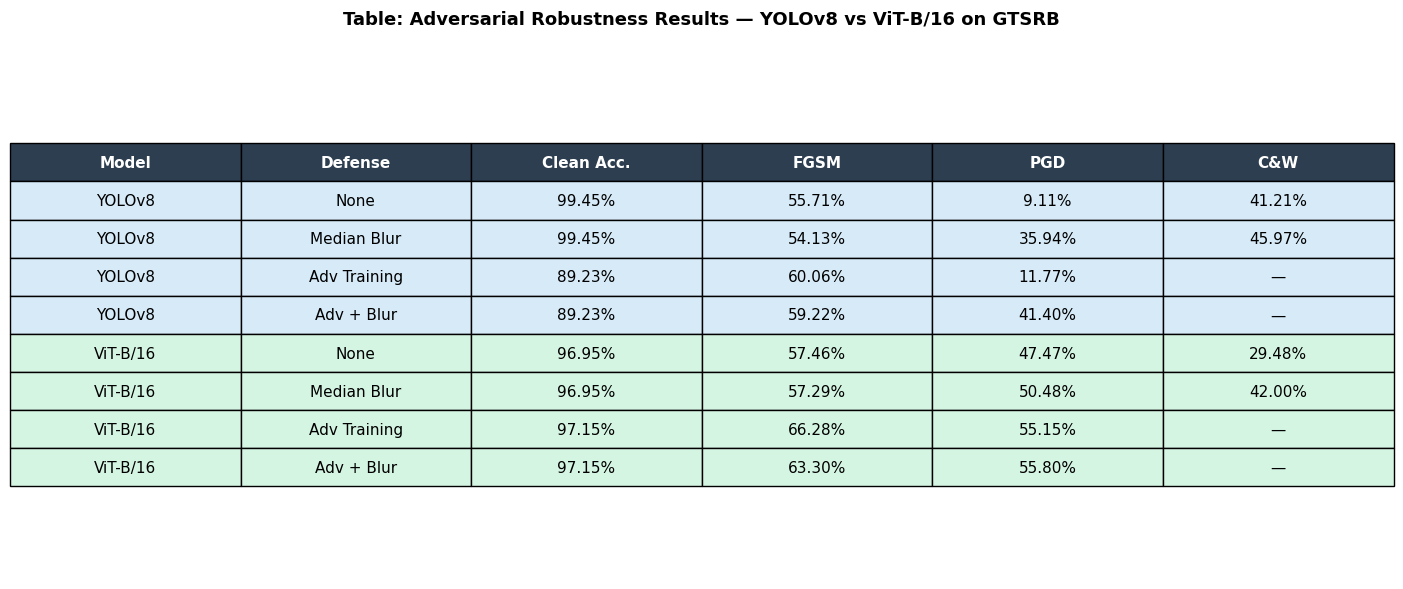

saved.


In [ ]:
# publication-style summary table matching Chen et al. format
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

columns = ['Model', 'Defense', 'Clean Acc.', 'FGSM', 'PGD', 'C&W']
rows = [
    ['YOLOv8', 'None',           '99.45%', '55.71%', '9.11%',  '41.21%'],
    ['YOLOv8', 'Median Blur',    '99.45%', '54.13%', '35.94%', '45.97%'],
    ['YOLOv8', 'Adv Training',   '89.23%', '60.06%', '11.77%', '—'],
    ['YOLOv8', 'Adv + Blur',     '89.23%', '59.22%', '41.40%', '—'],
    ['ViT-B/16', 'None',         '96.95%', '57.46%', '47.47%', '29.48%'],
    ['ViT-B/16', 'Median Blur',  '96.95%', '57.29%', '50.48%', '42.00%'],
    ['ViT-B/16', 'Adv Training', '97.15%', '66.28%', '55.15%', '—'],
    ['ViT-B/16', 'Adv + Blur',   '97.15%', '63.30%', '55.80%', '—'],
]

table = ax.table(
    cellText    = rows,
    colLabels   = columns,
    loc         = 'center',
    cellLoc     = 'center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# styling header
for j in range(len(columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# styling YOLO rows
for i in range(1, 5):
    for j in range(len(columns)):
        table[i, j].set_facecolor('#d6eaf8')

# styling ViT rows
for i in range(5, 9):
    for j in range(len(columns)):
        table[i, j].set_facecolor('#d5f5e3')

ax.set_title('Table: Adversarial Robustness Results — YOLOv8 vs ViT-B/16 on GTSRB',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/results_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

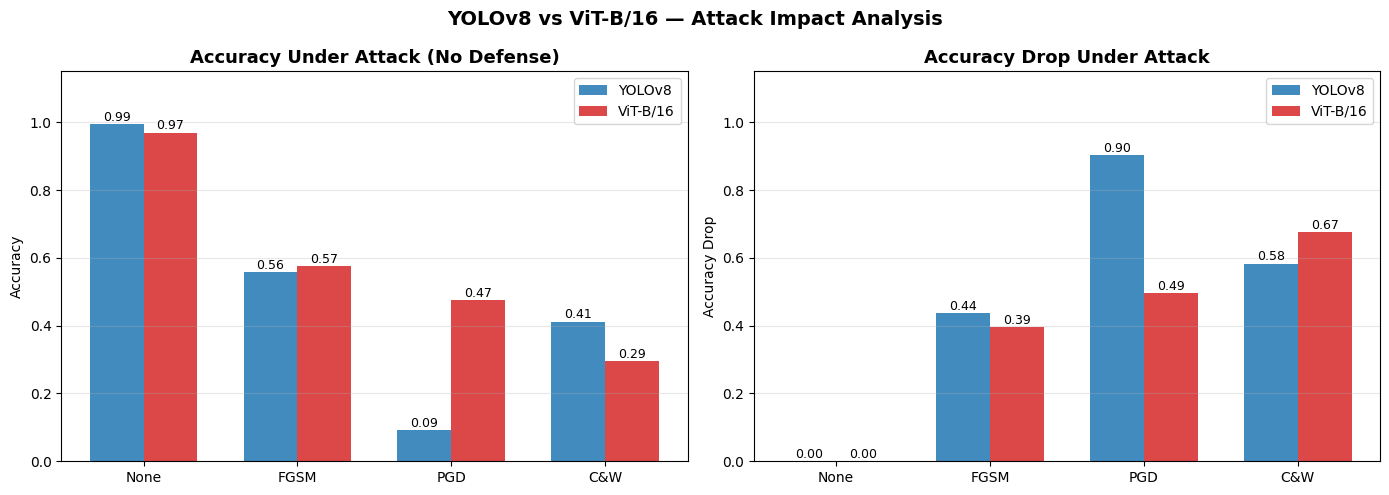

saved.


In [ ]:
# precision and recall style plot matching Chen et al. Fig 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attacks  = ['None', 'FGSM', 'PGD', 'C&W']

# YOLO metrics
yolo_acc     = [0.9945, 0.5571, 0.0911, 0.4121]

# ViT metrics
vit_acc      = [0.9695, 0.5746, 0.4747, 0.2948]

# accuracy drop
yolo_drop = [0, 0.9945-0.5571, 0.9945-0.0911, 0.9945-0.4121]
vit_drop  = [0, 0.9695-0.5746, 0.9695-0.4747, 0.9695-0.2948]

x     = np.arange(len(attacks))
width = 0.35

# left plot — raw accuracy
axes[0].bar(x - width/2, yolo_acc, width, label='YOLOv8',   color='#1f77b4', alpha=0.85)
axes[0].bar(x + width/2, vit_acc,  width, label='ViT-B/16', color='#d62728', alpha=0.85)
axes[0].set_title('Accuracy Under Attack (No Defense)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(attacks)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (y, v) in enumerate(zip(yolo_acc, vit_acc)):
    axes[0].text(i - width/2, y + 0.01, f'{y:.2f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

# right plot — accuracy drop
axes[1].bar(x - width/2, yolo_drop, width, label='YOLOv8',   color='#1f77b4', alpha=0.85)
axes[1].bar(x + width/2, vit_drop,  width, label='ViT-B/16', color='#d62728', alpha=0.85)
axes[1].set_title('Accuracy Drop Under Attack', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(attacks)
axes[1].set_ylabel('Accuracy Drop')
axes[1].set_ylim(0, 1.15)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
for i, (y, v) in enumerate(zip(yolo_drop, vit_drop)):
    axes[1].text(i - width/2, y + 0.01, f'{y:.2f}', ha='center', fontsize=9)
    axes[1].text(i + width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('YOLOv8 vs ViT-B/16 — Attack Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/attack_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

In [ ]:
# C&W on adversarially trained YOLO - running overnight
cw_yolo_adv = torchattacks.CW(yolo_adv_wrapper, c=1, kappa=0, steps=50, lr=0.01)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_yolo_adv(images, labels)
    outputs        = yolo_adv_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'YOLO adv trained - under C&W: {correct/total:.4f}')

YOLO adv trained - under C&W: 0.4584


In [ ]:
# reloading adversarially trained ViT
vit_adv = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=43, img_size=64)
vit_adv.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_research/vit_adv.pth'))
vit_adv = vit_adv.to(device)
vit_adv.eval()
print('vit_adv reloaded.')

vit_adv reloaded.


In [ ]:
# C&W on adversarially trained ViT - running overnight
cw_vit_adv = torchattacks.CW(vit_adv, c=1, kappa=0, steps=50, lr=0.01)

correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_vit_adv(images, labels)
    outputs        = vit_adv(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)

print(f'ViT adv trained - under C&W: {correct/total:.4f}')

KeyboardInterrupt: 

In [ ]:
# generating PGD adversarial examples from training set
pgd_train = torchattacks.PGD(vit_model, eps=8/255, alpha=2/255, steps=10)

pgd_images_list, pgd_labels_list = [], []

vit_model.eval()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_train(images, labels)
    pgd_images_list.append(adv_images.cpu())
    pgd_labels_list.append(labels.cpu())

pgd_images_tensor = torch.cat(pgd_images_list)
pgd_labels_tensor = torch.cat(pgd_labels_list)

print(f'generated {len(pgd_images_tensor)} PGD adversarial examples.')

generated 31367 PGD adversarial examples.


In [ ]:
# mixing clean + FGSM + PGD into one dataset
from torch.utils.data import TensorDataset, DataLoader

mixed_images = torch.cat([clean_images_tensor, adv_images_tensor, pgd_images_tensor])
mixed_labels = torch.cat([clean_labels_tensor, adv_labels_tensor, pgd_labels_tensor])

mixed_dataset = TensorDataset(mixed_images, mixed_labels)
mixed_loader  = DataLoader(mixed_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f'mixed dataset size: {len(mixed_dataset)} (clean + FGSM + PGD)')

mixed dataset size: 94101 (clean + FGSM + PGD)


In [ ]:
# lighter mixed dataset - FGSM + PGD only, no clean
mixed_images = torch.cat([adv_images_tensor, pgd_images_tensor])
mixed_labels = torch.cat([adv_labels_tensor, pgd_labels_tensor])

mixed_dataset = TensorDataset(mixed_images, mixed_labels)
mixed_loader  = DataLoader(mixed_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f'mixed dataset size: {len(mixed_dataset)}')

mixed dataset size: 62734


In [ ]:
# retraining ViT on FGSM+PGD mixed dataset for 10 epochs
vit_adv_mixed = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=43, img_size=64)
vit_adv_mixed = vit_adv_mixed.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(vit_adv_mixed.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

best_acc = 0.0
for epoch in range(10):
    vit_adv_mixed.train()
    correct, total = 0, 0
    for images, labels in mixed_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vit_adv_mixed(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    scheduler.step()

    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(vit_adv_mixed.state_dict(), '/content/drive/MyDrive/gtsrb_research/vit_adv_mixed.pth')

    print(f'epoch {epoch+1:02d}/10 | train acc: {train_acc:.4f}')

print(f'best train accuracy: {best_acc:.4f}')

epoch 01/10 | train acc: 0.7338
epoch 02/10 | train acc: 0.8366
epoch 03/10 | train acc: 0.8581
epoch 04/10 | train acc: 0.8686
epoch 05/10 | train acc: 0.8808
epoch 06/10 | train acc: 0.8855
epoch 07/10 | train acc: 0.8913
epoch 08/10 | train acc: 0.8964
epoch 09/10 | train acc: 0.8987
epoch 10/10 | train acc: 0.9005
best train accuracy: 0.9005


In [ ]:
# confirming vit_adv_mixed is saved in drive
import os
path = '/content/drive/MyDrive/gtsrb_research'
for item in os.listdir(path):
    print(item)

data
yolo_best.pt
yolo_last.pt
vit_best.pth
vit_adv.pth
yolo_adv.pt
yolo_adv2.pt
vit_adv2.pth
defense_comparison.png
head_to_head.png
best_defense.png
accuracy_drop_heatmap.png
full_comparison.png
defense_progression.png
results_table.png
attack_impact.png
vit_adv_mixed.pth
no_defense_results.png


In [ ]:
# evaluating ViT mixed adv training on test set
vit_adv_mixed = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=43, img_size=64)
vit_adv_mixed.load_state_dict(torch.load('/content/drive/MyDrive/gtsrb_research/vit_adv_mixed.pth'))
vit_adv_mixed = vit_adv_mixed.to(device)
vit_adv_mixed.eval()

# clean accuracy
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = vit_adv_mixed(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
print(f'ViT mixed adv - clean: {correct/total:.4f}')

# under FGSM
fgsm_vit_mixed = torchattacks.FGSM(vit_adv_mixed, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_vit_mixed(images, labels)
    outputs        = vit_adv_mixed(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT mixed adv - FGSM: {correct/total:.4f}')

# under PGD
pgd_vit_mixed = torchattacks.PGD(vit_adv_mixed, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_vit_mixed(images, labels)
    outputs        = vit_adv_mixed(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT mixed adv - PGD: {correct/total:.4f}')

ViT mixed adv - clean: 0.8652
ViT mixed adv - FGSM: 0.6458
ViT mixed adv - PGD: 0.5360


In [ ]:
# saving FGSM+PGD mixed dataset for YOLO to disk
import os
from torchvision.utils import save_image

save_path_yolo_mixed = '/content/gtsrb_adv_train_yolo_mixed'
os.makedirs(save_path_yolo_mixed, exist_ok=True)

class_names = train_dataset.classes

for i, (img, label) in enumerate(zip(adv_images_tensor, adv_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_yolo_mixed, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'fgsm_{i}.png'))

for i, (img, label) in enumerate(zip(pgd_images_tensor, pgd_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_yolo_mixed, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'pgd_{i}.png'))

print(f'saved {len(adv_images_tensor) + len(pgd_images_tensor)} mixed images for YOLO.')

saved 62734 mixed images for YOLO.


In [ ]:
# retraining YOLO on FGSM+PGD mixed dataset
from ultralytics import YOLO
import shutil

yolo_adv_mixed = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_best.pt')

yolo_adv_mixed.train(
    data    = '/content/gtsrb_adv_train_yolo_mixed',
    epochs  = 20,
    imgsz   = 64,
    batch   = 64,
    device  = 0,
    project = '/content/yolo_adv_mixed_results',
    name    = 'gtsrb_adv_mixed_run',
    save    = True
)

shutil.copy('/content/yolo_adv_mixed_results/gtsrb_adv_mixed_run/weights/best.pt',
            '/content/drive/MyDrive/gtsrb_research/yolo_adv_mixed.pt')
print('YOLO mixed adv weights saved to drive.')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gtsrb_adv_train_yolo_mixed, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/gtsrb_research/yolo_best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gtsrb_adv_mixed_run, nbs=64, nms=False, opset=None, optimize

In [ ]:
# evaluating YOLO mixed adv training on test set
yolo_adv_mixed_model   = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_adv_mixed.pt')
yolo_adv_mixed_pytorch = yolo_adv_mixed_model.model
yolo_adv_mixed_pytorch.train()

yolo_adv_mixed_wrapper = YOLOWrapper(yolo_adv_mixed_pytorch).to(device)

# clean accuracy
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs  = yolo_adv_mixed_wrapper(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
print(f'YOLO mixed adv - clean: {correct/total:.4f}')

# under FGSM
fgsm_yolo_mixed = torchattacks.FGSM(yolo_adv_mixed_wrapper, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_yolo_mixed(images, labels)
    outputs        = yolo_adv_mixed_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO mixed adv - FGSM: {correct/total:.4f}')

# under PGD
pgd_yolo_mixed = torchattacks.PGD(yolo_adv_mixed_wrapper, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_yolo_mixed(images, labels)
    outputs        = yolo_adv_mixed_wrapper(adv_images)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO mixed adv - PGD: {correct/total:.4f}')

YOLO mixed adv - clean: 0.8770
YOLO mixed adv - FGSM: 0.6365
YOLO mixed adv - PGD: 0.2446


In [ ]:
# YOLO mixed adv + median blur
fgsm_yolo_mixed = torchattacks.FGSM(yolo_adv_mixed_wrapper, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_yolo_mixed(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_adv_mixed_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO mixed adv + blur - FGSM: {correct/total:.4f}')

pgd_yolo_mixed = torchattacks.PGD(yolo_adv_mixed_wrapper, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_yolo_mixed(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_adv_mixed_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'YOLO mixed adv + blur - PGD: {correct/total:.4f}')

YOLO mixed adv + blur - FGSM: 0.6454
YOLO mixed adv + blur - PGD: 0.5135


In [ ]:
# ViT mixed adv + median blur
fgsm_vit_mixed = torchattacks.FGSM(vit_adv_mixed, eps=8/255)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = fgsm_vit_mixed(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_adv_mixed(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT mixed adv + blur - FGSM: {correct/total:.4f}')

pgd_vit_mixed = torchattacks.PGD(vit_adv_mixed, eps=8/255, alpha=2/255, steps=10)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = pgd_vit_mixed(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_adv_mixed(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
print(f'ViT mixed adv + blur - PGD: {correct/total:.4f}')

ViT mixed adv + blur - FGSM: 0.6496
ViT mixed adv + blur - PGD: 0.5781


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# professional color palette
BLUE   = '#2196F3'
RED    = '#F44336'
GREEN  = '#4CAF50'
ORANGE = '#FF9800'
PURPLE = '#9C27B0'
TEAL   = '#009688'

# all results
results = {
    'YOLOv8': {
        'No Defense':          {'Clean': 0.9945, 'FGSM': 0.5571, 'PGD': 0.0911, 'C&W': 0.4121},
        'Median Blur':         {'Clean': 0.9945, 'FGSM': 0.5413, 'PGD': 0.3594, 'C&W': 0.4597},
        'Adv Train (FGSM)':    {'Clean': 0.8923, 'FGSM': 0.6006, 'PGD': 0.1177, 'C&W': None},
        'Adv Train (FGSM+PGD)':{'Clean': 0.8770, 'FGSM': 0.6365, 'PGD': 0.2446, 'C&W': None},
        'Adv+Blur (FGSM)':     {'Clean': 0.8923, 'FGSM': 0.5922, 'PGD': 0.4140, 'C&W': None},
        'Adv+Blur (FGSM+PGD)': {'Clean': 0.8770, 'FGSM': 0.6454, 'PGD': 0.5135, 'C&W': None},
    },
    'ViT-B/16': {
        'No Defense':          {'Clean': 0.9695, 'FGSM': 0.5746, 'PGD': 0.4747, 'C&W': 0.2948},
        'Median Blur':         {'Clean': 0.9695, 'FGSM': 0.5729, 'PGD': 0.5048, 'C&W': 0.4200},
        'Adv Train (FGSM)':    {'Clean': 0.9715, 'FGSM': 0.6628, 'PGD': 0.5515, 'C&W': None},
        'Adv Train (FGSM+PGD)':{'Clean': 0.8652, 'FGSM': 0.6458, 'PGD': 0.5360, 'C&W': None},
        'Adv+Blur (FGSM)':     {'Clean': 0.9715, 'FGSM': 0.6330, 'PGD': 0.5580, 'C&W': None},
        'Adv+Blur (FGSM+PGD)': {'Clean': 0.8652, 'FGSM': 0.6496, 'PGD': 0.5781, 'C&W': None},
    }
}

print('data loaded.')

data loaded.


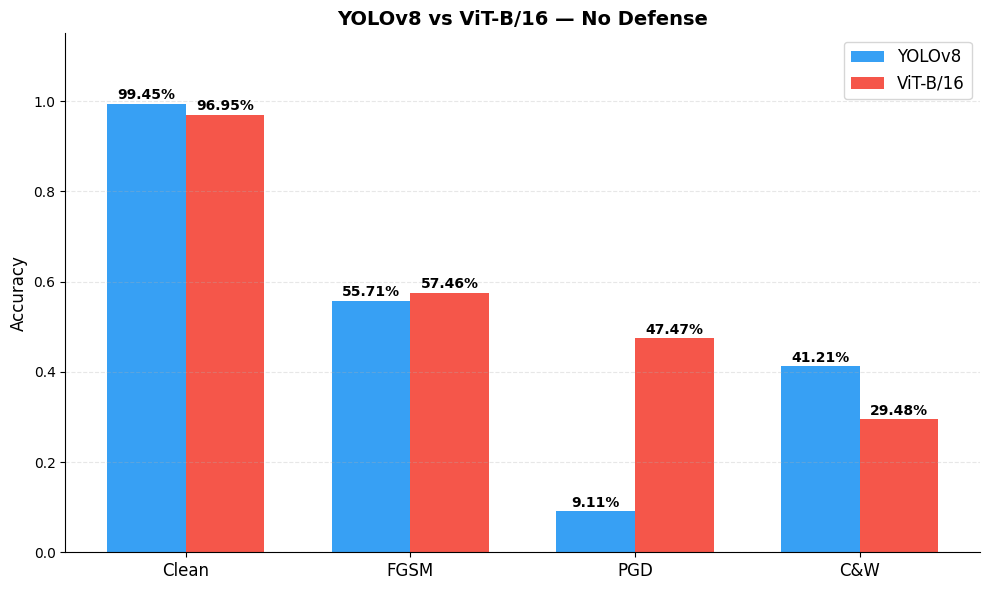

saved.


In [ ]:
# graph 1 - no defense comparison including C&W
attacks = ['Clean', 'FGSM', 'PGD', 'C&W']
yolo = [0.9945, 0.5571, 0.0911, 0.4121]
vit  = [0.9695, 0.5746, 0.4747, 0.2948]

x     = np.arange(len(attacks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, yolo, width, label='YOLOv8',   color=BLUE,  alpha=0.9)
bars2 = ax.bar(x + width/2, vit,  width, label='ViT-B/16', color=RED,   alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(attacks, fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('YOLOv8 vs ViT-B/16 — No Defense', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/graph1_no_defense.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

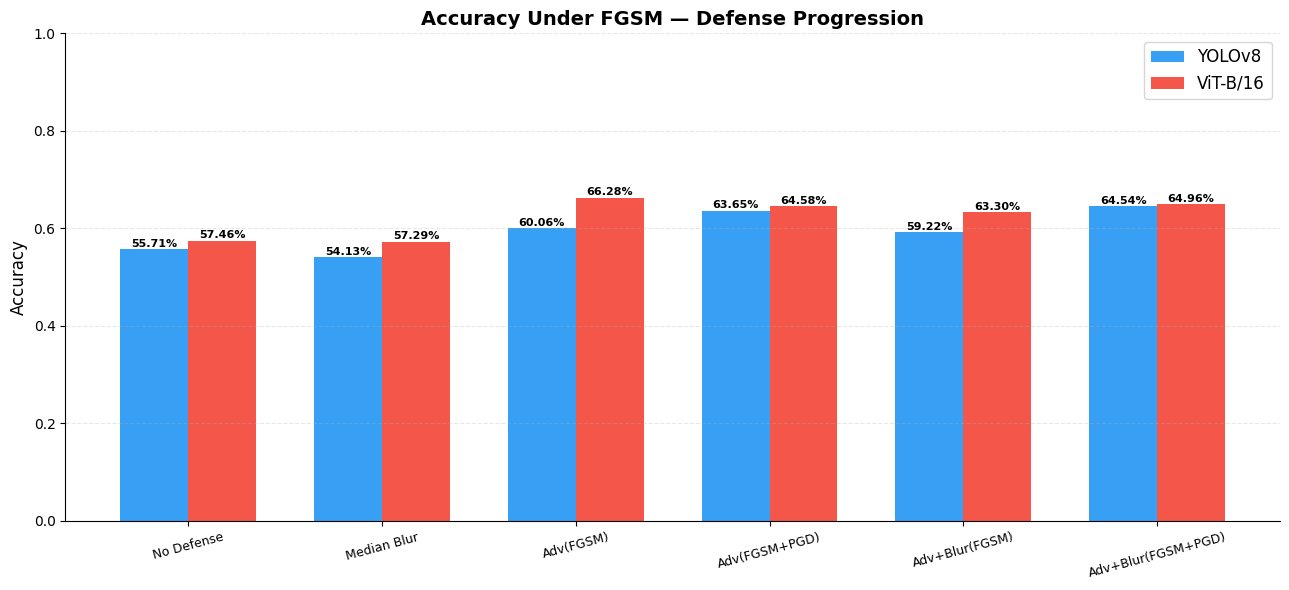

saved.


In [ ]:
# graph 2 - defense progression under FGSM
defenses = ['No Defense', 'Median Blur', 'Adv(FGSM)', 'Adv(FGSM+PGD)', 'Adv+Blur(FGSM)', 'Adv+Blur(FGSM+PGD)']
yolo_fgsm = [0.5571, 0.5413, 0.6006, 0.6365, 0.5922, 0.6454]
vit_fgsm  = [0.5746, 0.5729, 0.6628, 0.6458, 0.6330, 0.6496]

x     = np.arange(len(defenses))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, yolo_fgsm, width, label='YOLOv8',   color=BLUE, alpha=0.9)
bars2 = ax.bar(x + width/2, vit_fgsm,  width, label='ViT-B/16', color=RED,  alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(defenses, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Accuracy Under FGSM — Defense Progression', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/graph2_fgsm_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

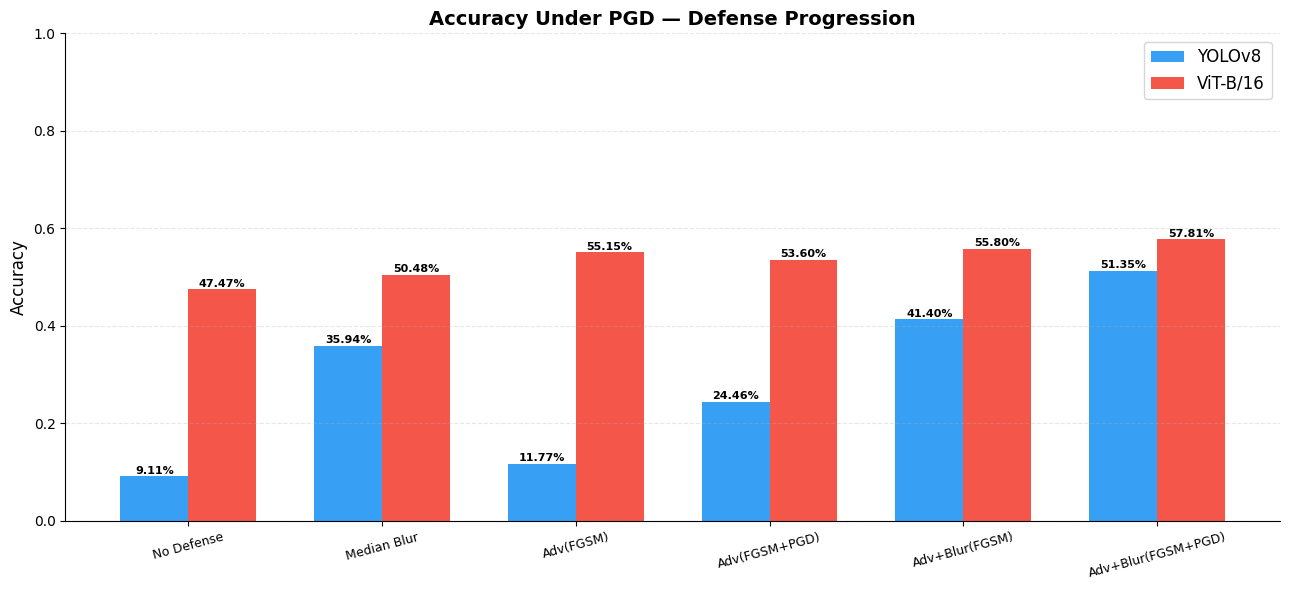

saved.


In [ ]:
# graph 3 - defense progression under PGD
yolo_pgd = [0.0911, 0.3594, 0.1177, 0.2446, 0.4140, 0.5135]
vit_pgd  = [0.4747, 0.5048, 0.5515, 0.5360, 0.5580, 0.5781]

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, yolo_pgd, width, label='YOLOv8',   color=BLUE, alpha=0.9)
bars2 = ax.bar(x + width/2, vit_pgd,  width, label='ViT-B/16', color=RED,  alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(defenses, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Accuracy Under PGD — Defense Progression', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/graph3_pgd_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

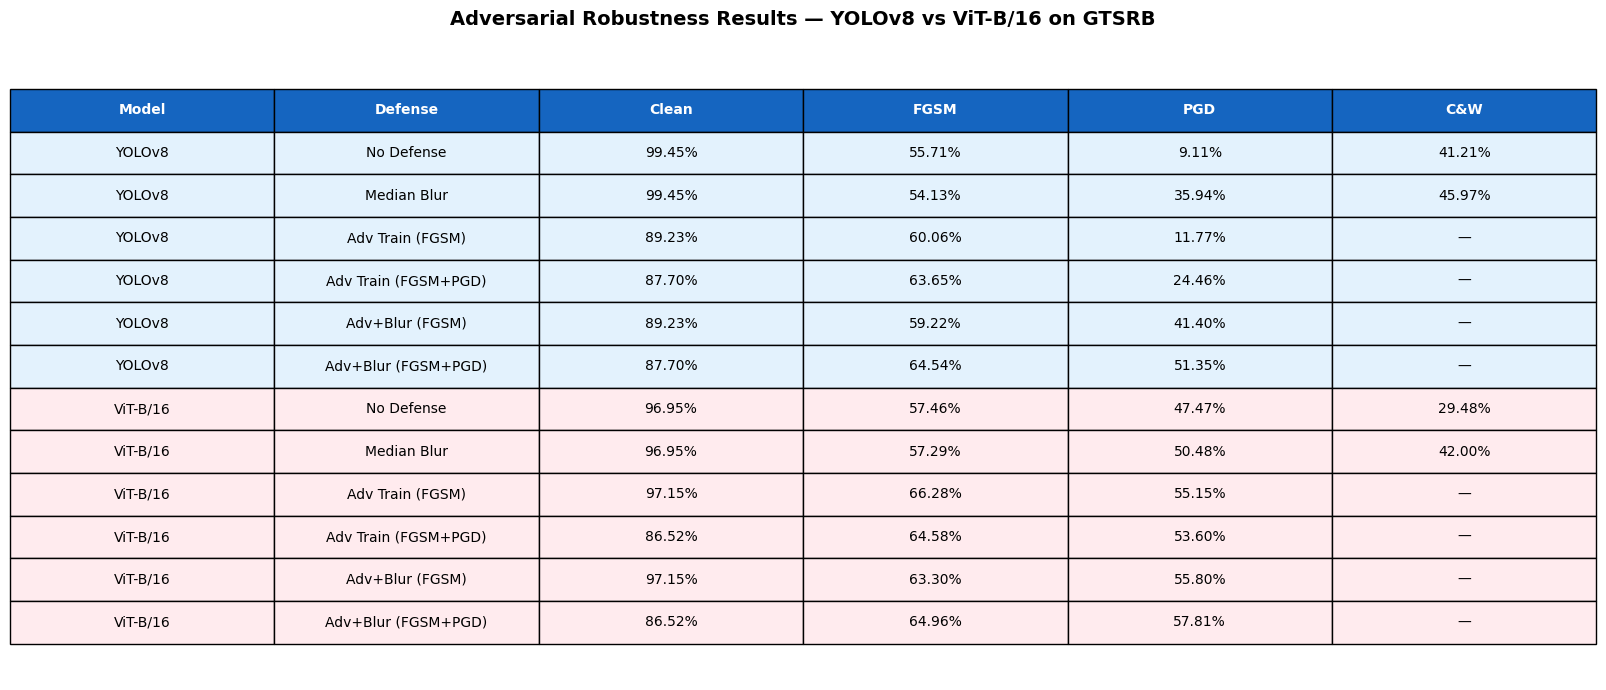

saved.


In [ ]:
# professional results table
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 7))
ax.axis('off')

columns = ['Model', 'Defense', 'Clean', 'FGSM', 'PGD', 'C&W']
rows = [
    ['YOLOv8',   'No Defense',           '99.45%', '55.71%', '9.11%',  '41.21%'],
    ['YOLOv8',   'Median Blur',           '99.45%', '54.13%', '35.94%', '45.97%'],
    ['YOLOv8',   'Adv Train (FGSM)',      '89.23%', '60.06%', '11.77%', '—'],
    ['YOLOv8',   'Adv Train (FGSM+PGD)', '87.70%', '63.65%', '24.46%', '—'],
    ['YOLOv8',   'Adv+Blur (FGSM)',       '89.23%', '59.22%', '41.40%', '—'],
    ['YOLOv8',   'Adv+Blur (FGSM+PGD)',  '87.70%', '64.54%', '51.35%', '—'],
    ['ViT-B/16', 'No Defense',           '96.95%', '57.46%', '47.47%', '29.48%'],
    ['ViT-B/16', 'Median Blur',           '96.95%', '57.29%', '50.48%', '42.00%'],
    ['ViT-B/16', 'Adv Train (FGSM)',      '97.15%', '66.28%', '55.15%', '—'],
    ['ViT-B/16', 'Adv Train (FGSM+PGD)', '86.52%', '64.58%', '53.60%', '—'],
    ['ViT-B/16', 'Adv+Blur (FGSM)',       '97.15%', '63.30%', '55.80%', '—'],
    ['ViT-B/16', 'Adv+Blur (FGSM+PGD)',  '86.52%', '64.96%', '57.81%', '—'],
]

table = ax.table(cellText=rows, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.2)

# header styling
for j in range(len(columns)):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

# YOLO rows
for i in range(1, 7):
    for j in range(len(columns)):
        table[i, j].set_facecolor('#E3F2FD')

# ViT rows
for i in range(7, 13):
    for j in range(len(columns)):
        table[i, j].set_facecolor('#FFEBEE')

ax.set_title('Adversarial Robustness Results — YOLOv8 vs ViT-B/16 on GTSRB',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/final_results_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

In [ ]:
# running all C&W evaluations and saving results automatically
import json
import torchattacks
from torchvision.transforms.functional import to_pil_image, to_tensor
from PIL import ImageFilter

def median_blur(images, kernel_size=3):
    blurred = []
    for img in images:
        pil_img     = to_pil_image(img.cpu())
        blurred_img = pil_img.filter(ImageFilter.MedianFilter(size=kernel_size))
        blurred.append(to_tensor(blurred_img))
    return torch.stack(blurred).to(images.device)

def eval_cw(model, loader, device, label):
    cw = torchattacks.CW(model, c=1, kappa=0, steps=50, lr=0.01)
    correct, total = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        adv_images     = cw(images, labels)
        outputs        = model(adv_images)
        correct       += (outputs.argmax(1) == labels).sum().item()
        total         += labels.size(0)
    acc = correct / total
    print(f'{label}: {acc:.4f}')
    return acc

cw_results = {}

# 1. ViT no defense
print('--- ViT no defense ---')
vit_model.eval()
cw_results['vit_no_defense'] = eval_cw(vit_model, test_loader, device, 'ViT no defense')

# 2. ViT no defense + blur
print('--- ViT median blur ---')
cw_vit = torchattacks.CW(vit_model, c=1, kappa=0, steps=50, lr=0.01)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_vit(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_model(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
cw_results['vit_median_blur'] = correct / total
print(f'ViT median blur: {cw_results["vit_median_blur"]:.4f}')

# 3. ViT adv training FGSM
print('--- ViT adv train FGSM ---')
vit_adv.eval()
cw_results['vit_adv_fgsm'] = eval_cw(vit_adv, test_loader, device, 'ViT adv FGSM')

# 4. ViT adv training FGSM + blur
print('--- ViT adv train FGSM + blur ---')
cw_vit_adv = torchattacks.CW(vit_adv, c=1, kappa=0, steps=50, lr=0.01)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_vit_adv(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_adv(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
cw_results['vit_adv_fgsm_blur'] = correct / total
print(f'ViT adv FGSM + blur: {cw_results["vit_adv_fgsm_blur"]:.4f}')

# 5. ViT adv training FGSM+PGD
print('--- ViT adv train FGSM+PGD ---')
vit_adv_mixed.eval()
cw_results['vit_adv_mixed'] = eval_cw(vit_adv_mixed, test_loader, device, 'ViT adv mixed')

# 6. ViT adv training FGSM+PGD + blur
print('--- ViT adv train FGSM+PGD + blur ---')
cw_vit_mixed = torchattacks.CW(vit_adv_mixed, c=1, kappa=0, steps=50, lr=0.01)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_vit_mixed(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = vit_adv_mixed(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
cw_results['vit_adv_mixed_blur'] = correct / total
print(f'ViT adv mixed + blur: {cw_results["vit_adv_mixed_blur"]:.4f}')

# 7. YOLO no defense + blur
print('--- YOLO median blur ---')
cw_yolo = torchattacks.CW(yolo_wrapper, c=1, kappa=0, steps=50, lr=0.01)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_yolo(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
cw_results['yolo_median_blur'] = correct / total
print(f'YOLO median blur: {cw_results["yolo_median_blur"]:.4f}')

# 8. YOLO adv training FGSM
print('--- YOLO adv train FGSM ---')
cw_results['yolo_adv_fgsm'] = eval_cw(yolo_adv_wrapper, test_loader, device, 'YOLO adv FGSM')

# 9. YOLO adv training FGSM + blur
print('--- YOLO adv train FGSM + blur ---')
cw_yolo_adv = torchattacks.CW(yolo_adv_wrapper, c=1, kappa=0, steps=50, lr=0.01)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_yolo_adv(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_adv_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
cw_results['yolo_adv_fgsm_blur'] = correct / total
print(f'YOLO adv FGSM + blur: {cw_results["yolo_adv_fgsm_blur"]:.4f}')

# 10. YOLO adv training FGSM+PGD
print('--- YOLO adv train FGSM+PGD ---')
cw_results['yolo_adv_mixed'] = eval_cw(yolo_adv_mixed_wrapper, test_loader, device, 'YOLO adv mixed')

# 11. YOLO adv training FGSM+PGD + blur
print('--- YOLO adv train FGSM+PGD + blur ---')
cw_yolo_mixed = torchattacks.CW(yolo_adv_mixed_wrapper, c=1, kappa=0, steps=50, lr=0.01)
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_yolo_mixed(images, labels)
    blurred        = median_blur(adv_images)
    outputs        = yolo_adv_mixed_wrapper(blurred)
    correct       += (outputs.argmax(1) == labels).sum().item()
    total         += labels.size(0)
cw_results['yolo_adv_mixed_blur'] = correct / total
print(f'YOLO adv mixed + blur: {cw_results["yolo_adv_mixed_blur"]:.4f}')

# saving all results to drive
import json
with open('/content/drive/MyDrive/gtsrb_research/cw_results.json', 'w') as f:
    json.dump(cw_results, f, indent=4)

print('\n--- ALL C&W RESULTS ---')
for k, v in cw_results.items():
    print(f'{k}: {v:.4f}')
print('\nall results saved to drive.')

--- ViT no defense ---
ViT no defense: 0.2948
--- ViT median blur ---
ViT median blur: 0.4200
--- ViT adv train FGSM ---
ViT adv FGSM: 0.3090
--- ViT adv train FGSM + blur ---
ViT adv FGSM + blur: 0.5515
--- ViT adv train FGSM+PGD ---
ViT adv mixed: 0.2880
--- ViT adv train FGSM+PGD + blur ---
ViT adv mixed + blur: 0.5245
--- YOLO median blur ---
YOLO median blur: 0.4595
--- YOLO adv train FGSM ---
YOLO adv FGSM: 0.4575
--- YOLO adv train FGSM + blur ---
YOLO adv FGSM + blur: 0.5004
--- YOLO adv train FGSM+PGD ---
YOLO adv mixed: 0.5618
--- YOLO adv train FGSM+PGD + blur ---
YOLO adv mixed + blur: 0.5049

--- ALL C&W RESULTS ---
vit_no_defense: 0.2948
vit_median_blur: 0.4200
vit_adv_fgsm: 0.3090
vit_adv_fgsm_blur: 0.5515
vit_adv_mixed: 0.2880
vit_adv_mixed_blur: 0.5245
yolo_median_blur: 0.4595
yolo_adv_fgsm: 0.4575
yolo_adv_fgsm_blur: 0.5004
yolo_adv_mixed: 0.5618
yolo_adv_mixed_blur: 0.5049

all results saved to drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


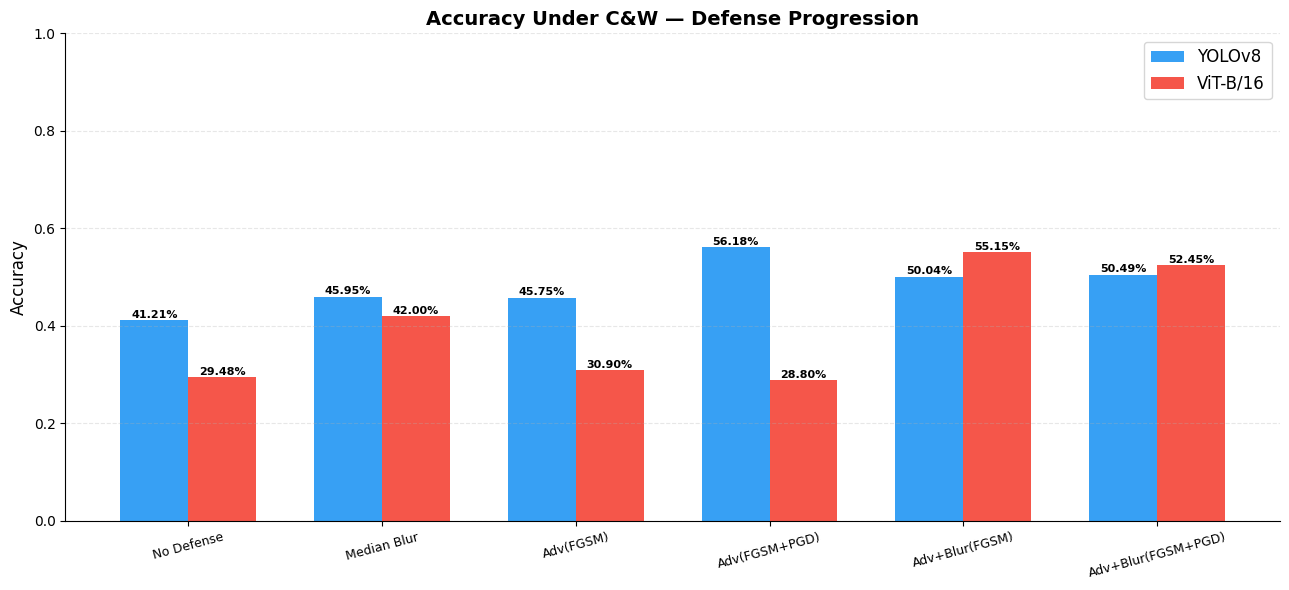

saved.


In [ ]:
# defense progression under C&W
import matplotlib.pyplot as plt
import numpy as np

BLUE  = '#2196F3'
RED   = '#F44336'

defenses = ['No Defense', 'Median Blur', 'Adv(FGSM)', 'Adv(FGSM+PGD)', 'Adv+Blur(FGSM)', 'Adv+Blur(FGSM+PGD)']

yolo_cw = [0.4121, 0.4595, 0.4575, 0.5618, 0.5004, 0.5049]
vit_cw  = [0.2948, 0.4200, 0.3090, 0.2880, 0.5515, 0.5245]

x     = np.arange(len(defenses))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, yolo_cw, width, label='YOLOv8',   color=BLUE, alpha=0.9)
bars2 = ax.bar(x + width/2, vit_cw,  width, label='ViT-B/16', color=RED,  alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2%}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(defenses, fontsize=9, rotation=15)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Accuracy Under C&W — Defense Progression', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gtsrb_research/graph4_cw_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved.')

In [ ]:
!pip install -q ultralytics timm torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 16.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is in

In [ ]:
# setting up everything
import os, torch, timm
import pandas as pd
from PIL import Image
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, random_split
import torchattacks
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transforms_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.3337, 0.3064, 0.3171],
                         [0.2672, 0.2564, 0.2629])
])

class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None, class_to_idx=None):
        self.df           = pd.read_csv(csv_path)
        self.img_dir      = img_dir
        self.transform    = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Path'].split('/')[-1]
        img_path = os.path.join(self.img_dir, img_name)
        image    = Image.open(img_path).convert('RGB')
        label    = self.class_to_idx[str(int(self.df.iloc[idx]['ClassId']))]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset  = ImageFolder('/content/gtsrb/train', transform=transforms_64)
class_to_idx   = train_dataset.class_to_idx
class_names    = train_dataset.classes
train_size     = int(0.8 * len(train_dataset))
val_size       = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

test_dataset = GTSRBTestDataset(
    csv_path     = '/content/gtsrb/Test.csv',
    img_dir      = '/content/gtsrb/test',
    transform    = transforms_64,
    class_to_idx = class_to_idx
)

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_subset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

print('dataset ready.')

FileNotFoundError: [Errno 2] No such file or directory: '/content/gtsrb/train'

In [ ]:
# generating C&W training examples and retraining both models
import torch
import timm
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import TensorDataset, DataLoader
from ultralytics import YOLO
from torchvision.utils import save_image
import torchattacks
import shutil
import os
import json

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── STEP 1: generate C&W training examples ──────────────────────────────
print('=== STEP 1: Generating C&W adversarial training examples ===')

cw_train = torchattacks.CW(vit_model, c=1, kappa=0, steps=50, lr=0.01)

cw_images_list, cw_labels_list = [], []
vit_model.eval()

for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)
    adv_images     = cw_train(images, labels)
    cw_images_list.append(adv_images.cpu())
    cw_labels_list.append(labels.cpu())
    if batch_idx % 50 == 0:
        print(f'  batch {batch_idx}/{len(train_loader)}')

cw_images_tensor = torch.cat(cw_images_list)
cw_labels_tensor = torch.cat(cw_labels_list)
print(f'generated {len(cw_images_tensor)} C&W examples.')

# ── STEP 2: save C&W examples to disk for YOLO ──────────────────────────
print('\n=== STEP 2: Saving C&W examples to disk ===')

save_path_cw = '/content/gtsrb_cw_train'
os.makedirs(save_path_cw, exist_ok=True)
class_names = train_dataset.classes

for i, (img, label) in enumerate(zip(cw_images_tensor, cw_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_cw, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'cw_{i}.png'))

print(f'saved {len(cw_images_tensor)} C&W images to disk.')

# ── STEP 3: retrain ViT on FGSM+PGD+C&W mix ────────────────────────────
print('\n=== STEP 3: Retraining ViT on FGSM+PGD+C&W mix ===')

mixed_images = torch.cat([adv_images_tensor, pgd_images_tensor, cw_images_tensor])
mixed_labels = torch.cat([adv_labels_tensor, pgd_labels_tensor, cw_labels_tensor])

mixed_dataset = TensorDataset(mixed_images, mixed_labels)
mixed_loader  = DataLoader(mixed_dataset, batch_size=64, shuffle=True, num_workers=2)

vit_full = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=43, img_size=64)
vit_full = vit_full.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(vit_full.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

best_acc = 0.0
for epoch in range(10):
    vit_full.train()
    correct, total = 0, 0
    for images, labels in mixed_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vit_full(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    train_acc = correct / total
    scheduler.step()
    if train_acc > best_acc:
        best_acc = train_acc
        torch.save(vit_full.state_dict(), '/content/drive/MyDrive/gtsrb_research/vit_full_mix.pth')
    print(f'ViT epoch {epoch+1:02d}/10 | train acc: {train_acc:.4f}')

print(f'ViT best: {best_acc:.4f}')

# ── STEP 4: retrain YOLO on FGSM+PGD+C&W mix ───────────────────────────
print('\n=== STEP 4: Retraining YOLO on FGSM+PGD+C&W mix ===')

# save FGSM+PGD+C&W to one folder
save_path_full = '/content/gtsrb_full_mix'
os.makedirs(save_path_full, exist_ok=True)

for i, (img, label) in enumerate(zip(adv_images_tensor, adv_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_full, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'fgsm_{i}.png'))

for i, (img, label) in enumerate(zip(pgd_images_tensor, pgd_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_full, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'pgd_{i}.png'))

for i, (img, label) in enumerate(zip(cw_images_tensor, cw_labels_tensor)):
    class_name = class_names[label.item()]
    class_dir  = os.path.join(save_path_full, class_name)
    os.makedirs(class_dir, exist_ok=True)
    save_image(img, os.path.join(class_dir, f'cw_{i}.png'))

print('all images saved to disk.')

yolo_full = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_best.pt')
yolo_full.train(
    data    = '/content/gtsrb_full_mix',
    epochs  = 20,
    imgsz   = 64,
    batch   = 64,
    device  = 0,
    project = '/content/yolo_full_mix_results',
    name    = 'gtsrb_full_mix_run',
    save    = True
)

shutil.copy('/content/yolo_full_mix_results/gtsrb_full_mix_run/weights/best.pt',
            '/content/drive/MyDrive/gtsrb_research/yolo_full_mix.pt')
print('YOLO full mix saved to drive.')

# ── STEP 5: evaluate both models ────────────────────────────────────────
print('\n=== STEP 5: Evaluating both models ===')

class YOLOWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        out = self.model(x)
        if isinstance(out, tuple):
            return out[0]
        return out

yolo_full_model   = YOLO('/content/drive/MyDrive/gtsrb_research/yolo_full_mix.pt')
yolo_full_pytorch = yolo_full_model.model
yolo_full_pytorch.train()
yolo_full_wrapper = YOLOWrapper(yolo_full_pytorch).to(device)

vit_full.eval()

final_results = {}

for model_name, model in [('ViT_full_mix', vit_full), ('YOLO_full_mix', yolo_full_wrapper)]:
    final_results[model_name] = {}

    # clean
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    final_results[model_name]['clean'] = correct / total
    print(f'{model_name} clean: {correct/total:.4f}')

    # FGSM
    fgsm = torchattacks.FGSM(model, eps=8/255)
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        adv_images     = fgsm(images, labels)
        outputs        = model(adv_images)
        correct       += (outputs.argmax(1) == labels).sum().item()
        total         += labels.size(0)
    final_results[model_name]['fgsm'] = correct / total
    print(f'{model_name} FGSM: {correct/total:.4f}')

    # PGD
    pgd = torchattacks.PGD(model, eps=8/255, alpha=2/255, steps=10)
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        adv_images     = pgd(images, labels)
        outputs        = model(adv_images)
        correct       += (outputs.argmax(1) == labels).sum().item()
        total         += labels.size(0)
    final_results[model_name]['pgd'] = correct / total
    print(f'{model_name} PGD: {correct/total:.4f}')

    # C&W
    cw = torchattacks.CW(model, c=1, kappa=0, steps=50, lr=0.01)
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        adv_images     = cw(images, labels)
        outputs        = model(adv_images)
        correct       += (outputs.argmax(1) == labels).sum().item()
        total         += labels.size(0)
    final_results[model_name]['cw'] = correct / total
    print(f'{model_name} C&W: {correct/total:.4f}')

# saving all results
import json
with open('/content/drive/MyDrive/gtsrb_research/full_mix_results.json', 'w') as f:
    json.dump(final_results, f, indent=4)

print('\n=== ALL DONE ===')
print(json.dumps(final_results, indent=4))

=== STEP 1: Generating C&W adversarial training examples ===


NameError: name 'vit_model' is not defined

In [ ]:
%%javascript
function ClickConnect(){
    console.log("Keeping Colab alive...");
    document.querySelector("colab-toolbar-button#connect").click()
}
setInterval(ClickConnect, 60000)